In [1]:
%load_ext autoreload
%autoreload 2

from noise import *
from pathlib import Path 
import json
from data import *
from trackers import *

import matplotlib.pyplot as plt
import numpy as np
import pywt
import ptwt

# from main import *

/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_exp(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    return args_dict


args = load_exp("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda0_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "best")

## Testing covariance

In [3]:
train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=args["horizontal_flip"], data_subset=eval(args["data_subset"]),
    train_batch_size=args["train_batch_size"], test_batch_size=args["test_batch_size"], num_workers=args["num_workers"], seed=1
)

images = next(iter(train_dataloader))  # load for testing things.
C, H, W = 3, 32, 32
shape = (images[0].shape[0], C * H* W)
device = 'cuda'

min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)

covariance = spatial_corr_covariance(spatial_size=shape[-2], box_size=12, var_box=1, device=device, var_clean=1e-3)
noisy_sampler = MultipleColoredGaussianSamplerWithInput(noise_covariance=covariance)

In [19]:
from scipy.linalg import toeplitz

## downscale - super resolution ##
blur_by = int(2)
img_dim = images[0][0][0].view(-1).shape[0]
img_size = images[0][0].shape[-1]
print(img_size)
H = torch.zeros((img_dim // (blur_by**2), img_dim))
H.shape
for i in range(img_size  // blur_by):
    for j in range(img_size // blur_by):
        for i_inc in range(blur_by):
            for j_inc in range(blur_by):
                H[i * img_size // blur_by + j, (blur_by*i + i_inc) * img_size + (blur_by*j + j_inc)] = (1/blur_by**2)

# Deblurring

def kernel_to_matrix(F, I_row_num, I_col_num):
    """
    Arg:
    F -- numpy 2D matrix - kernel of the blur
    I_row_num - number of rows in signal
    I_col_num - number of cols in signal
    
    Returns: 
    output -- 2D numpy matrix, which operates on a signal I of size 
    """

    # number of columns and rows of the filter
    F_row_num, F_col_num = F.shape

    #  calculate the output dimensions
    output_row_num = I_row_num + F_row_num - 1
    output_col_num = I_col_num + F_col_num - 1
    #if print_ir: print('output dimension:', output_row_num, output_col_num)

    # zero pad the filter
    F_zero_padded = np.pad(F, ((output_row_num - F_row_num, 0),
                               (0, output_col_num - F_col_num)),
                            'constant', constant_values=0)
    #if print_ir: print('F_zero_padded: ', F_zero_padded)

    # use each row of the zero-padded F to creat a toeplitz matrix. 
    #  Number of columns in this matrices are same as numbe of columns of input signal
    toeplitz_list = []
    for i in range(F_zero_padded.shape[0]-1, -1, -1): # iterate from last row to the first row
        c = F_zero_padded[i, :] # i th row of the F 
        r = np.r_[c[0], np.zeros(I_col_num-1)] # first row for the toeplitz fuction should be defined otherwise
                                                            # the result is wrong
        toeplitz_m = toeplitz(c,r) # this function is in scipy.linalg library
        toeplitz_list.append(toeplitz_m)
        #if print_ir: print('F '+ str(i)+'\n', toeplitz_m)

        # doubly blocked toeplitz indices: 
    #  this matrix defines which toeplitz matrix from toeplitz_list goes to which part of the doubly blocked
    c = range(1, F_zero_padded.shape[0]+1)
    r = np.r_[c[0], np.zeros(I_row_num-1, dtype=int)]
    doubly_indices = toeplitz(c, r)
    #if print_ir: print('doubly indices \n', doubly_indices)

    ## creat doubly blocked matrix with zero values
    toeplitz_shape = toeplitz_list[0].shape # shape of one toeplitz matrix
    h = toeplitz_shape[0]*doubly_indices.shape[0]
    w = toeplitz_shape[1]*doubly_indices.shape[1]
    doubly_blocked_shape = [h, w]
    doubly_blocked = np.zeros(doubly_blocked_shape)

    # tile toeplitz matrices for each row in the doubly blocked matrix
    b_h, b_w = toeplitz_shape # hight and withs of each block
    for i in range(doubly_indices.shape[0]):
        for j in range(doubly_indices.shape[1]):
            start_i = i * b_h
            start_j = j * b_w
            end_i = start_i + b_h
            end_j = start_j + b_w
            doubly_blocked[start_i: end_i, start_j:end_j] = toeplitz_list[doubly_indices[i,j]-1]

    return doubly_blocked

def get_custom_kernel(type = "gauss", dim = 64):
    kernel = 0
    if type == "14641":
        kernel = np.array([[1, 4, 6, 4, 1]])
        kernel = np.matmul(kernel.transpose(1, 0), kernel) / 256.0
    elif type == "uniform":
        kernel = np.array([[1, 1, 1, 1, 1]])
        kernel = np.matmul(kernel.transpose(1, 0), kernel) / 25.0
    elif type == "gauss":
        #sigma 10
        kernel = np.array([[0.03920520445985253,0.03979771524812676,0.0399972021259645,0.03979771524812676,0.03920520445985253],
                           [0.03979771524812676,0.04039918069022969,0.04060168242614218,0.04039918069022969,0.03979771524812676],
                           [0.0399972021259645,0.04060168242614218,0.04080519920622999,0.04060168242614218,0.0399972021259645],
                           [0.03979771524812676,0.04039918069022969,0.04060168242614218,0.04039918069022969,0.03979771524812676],
                           [0.03920520445985253,0.03979771524812676,0.0399972021259645,0.03979771524812676,0.03920520445985253]])
    H = kernel_to_matrix(kernel, dim, dim)
    H = H[[row*(dim+4)+col for row in range(2, dim+2) for col in range(2,dim+2)], :]
    return H
    
# H = torch.from_numpy(get_custom_kernel(type="14641", dim = img_size)).type(torch.FloatTensor)

HtH = torch.t(H) @ H
# H_fourier = torch.fft.fft2(torch.linalg.inv(H), norm="ortho")

H_4d = HtH.view(32,32,32,32)

32


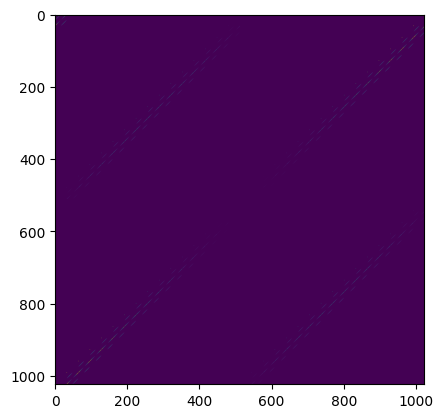

In [21]:
H_fourier = torch.fft.fftn(torch.fft.fftn(H_4d, dim = (-2, -1)), dim = (0, 1))

plt.imshow(1e10 * torch.abs(H_fourier.view(1024, 1024)))
# torch.abs(H_fourier.view(1024, 1024))

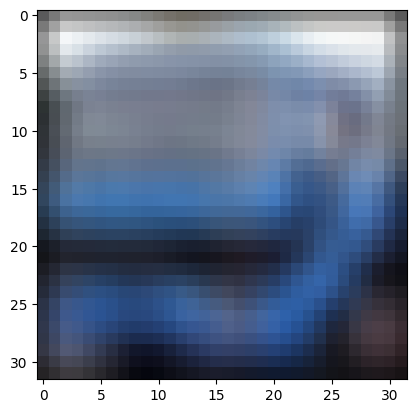

In [94]:
y = H @ images[0][0].view(3, -1).transpose(1, 0)
y = y.permute(1,0).view(3, int(np.sqrt(y.shape[0])), int(np.sqrt(y.shape[0])))

plt.imshow(y.numpy().transpose(1, 2, 0))

In [5]:
mse_var = noise_level_sampler.sample_noise_levels((1, 3 * 32 * 32), 'cpu').variance # This generate samples converted to the MSE unit
psnr_var = -10 * np.log10(mse_var).view(-1)
mse_var = mse_var.view(-1)

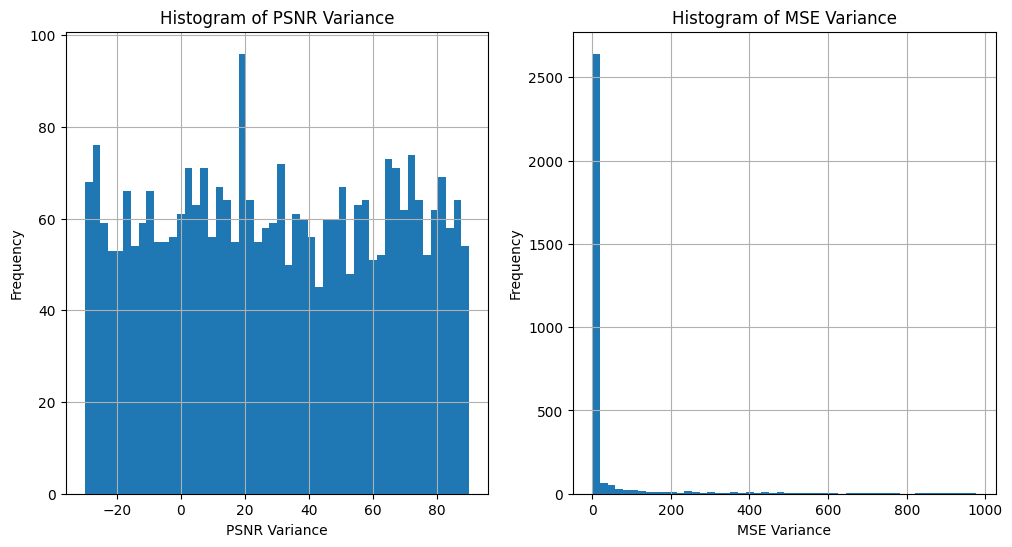

In [6]:
# Plot histogram of noise levels
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].hist(psnr_var, bins=50)
ax[0].set_xlabel('PSNR Variance')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Histogram of PSNR Variance')
ax[0].grid(True)

ax[1].hist(mse_var, bins=50)
ax[1].set_xlabel('MSE Variance')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Histogram of MSE Variance')
ax[1].grid(True)

In [7]:
args['noise_sampler']

'WhiteGaussianSampler()'

In [8]:
batch_test = 10
CHW = 3 * 32 * 32
sampler = 'ColoredGaussian'
# sampler = args['noise_sampler']

if sampler == args['noise_sampler']: #White sampler
    noisy_sampler: NoisySampler = eval(args['noise_sampler'])
    noise_level = noise_level_sampler.sample_noise_levels((images[0].shape[0], 1), 'cpu')
    samples = noisy_sampler.sample_noisy(images[0], noise_level, ())
else:
    shape = (images[0][0:batch_test].shape[0], CHW)
    noise_level = noise_level_sampler.sample_noise_levels((images[0].shape[0], 1), 'cpu')
    noisy_sampler = ColoredGaussianSampler(noise_level_sampler, shape = shape)
    # cov = noisy_sampler.sample_cov('cpu')
    samples = noisy_sampler.sample_noisy(images[0][0:batch_test])

In [ ]:
time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")

min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)

shape = (images[0].shape[0], CHW)
noisy_sampler = ColoredGaussianSampler(noise_level_sampler, shape = shape)

In [32]:
for batch in noisy_loader(train_dataloader, noise_level_sampler, noisy_sampler, time_tracker):

    input = ColoredModelInput(noisy=batch.noisy, colored_noise_level=batch.noise_level)
    break

In [33]:
input.colored_noise_level

## Testing Wavelets

In [49]:
train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=args["horizontal_flip"], data_subset=eval(args["data_subset"]),
    train_batch_size=args["train_batch_size"], test_batch_size=args["test_batch_size"], num_workers=args["num_workers"], seed=1
)

images = next(iter(train_dataloader))  # load for testing things.
C, H, W = 3, 32, 32
shape = (images[0].shape[0], C * H* W)
device = 'cuda'

min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)

covariance = spatial_corr_covariance(spatial_size=H, box_size=12, var_box=1, device=device, var_clean=1e-3)
noisy_sampler = MultipleColoredGaussianSamplerWithInput(noise_covariance=covariance)

In [134]:
def generate_2d_polynomial(
    resolution: int = 32,
    coefficients: dict = None,
    x_range: tuple = (0.0, 1.0),
    y_range: tuple = (0.0, 1.0)
) -> torch.Tensor:
    """
    Generates a 2D 3rd-order polynomial surface as a PyTorch tensor.

    The polynomial function is:
    P(x, y) = c00 + c10*x + c01*y + c20*x^2 + c11*x*y + c02*y^2 +
              c30*x^3 + c21*x^2*y + c12*x*y^2 + c03*y^3

    Args:
        resolution (int): The resolution of the 2D grid (e.g., 32 for 32x32).
        coefficients (dict, optional): A dictionary of coefficients for the polynomial terms.
                                      Keys should match the coefficient names (e.g., 'c00', 'c10').
                                      If a coefficient is not provided, it defaults to 0.0.
                                      Default coefficients create a simple diagonal gradient.
        x_range (tuple): A tuple (min_x, max_x) defining the range for the x-coordinates.
        y_range (tuple): A tuple (min_y, max_y) defining the range for the y-coordinates.

    Returns:
        torch.Tensor: A 2D PyTorch tensor of shape (resolution, resolution)
                      representing the polynomial surface.
    """
    # Default coefficients for a simple diagonal gradient if none are provided
    default_coefficients = {
        'c00': 0.0, 'c10': 1.0, 'c01': 1.0,
        'c20': 0.0, 'c11': 0.0, 'c02': 0.0,
        'c30': 0.0, 'c21': 0.0, 'c12': 0.0, 'c03': 0.0
    }

    # Update default coefficients with any user-provided coefficients
    if coefficients is None:
        coeffs = default_coefficients
    else:
        coeffs = {**default_coefficients, **coefficients}

    # Create a grid of x and y coordinates
    # torch.linspace creates evenly spaced numbers over a specified interval.
    x_coords = torch.linspace(x_range[0], x_range[1], resolution)
    y_coords = torch.linspace(y_range[0], y_range[1], resolution)

    # Create a 2D meshgrid from the 1D coordinate arrays
    # X and Y will be (resolution, resolution) tensors
    X, Y = torch.meshgrid(x_coords, y_coords, indexing='xy')

    # Calculate the polynomial values element-wise
    # Each term is multiplied by its corresponding coefficient
    P = (
        coeffs['c00'] +
        coeffs['c10'] * X +
        coeffs['c01'] * Y +
        coeffs['c20'] * X**2 +
        coeffs['c11'] * X * Y +
        coeffs['c02'] * Y**2 +
        coeffs['c30'] * X**3 +
        coeffs['c21'] * X**2 * Y +
        coeffs['c12'] * X * Y**2 +
        coeffs['c03'] * Y**3
    )

    return P


def generate_1d_polynomial(
    resolution: int = 32,
    coefficients: dict = None,
    x_range: tuple = (0.0, 1.0),
) -> torch.Tensor:
    """
    Generates a 2D 3rd-order polynomial surface as a PyTorch tensor.

    The polynomial function is:
    P(x, y) = c00 + c10*x + c01*y + c20*x^2 + c11*x*y + c02*y^2 +
              c30*x^3 + c21*x^2*y + c12*x*y^2 + c03*y^3

    Args:
        resolution (int): The resolution of the 2D grid (e.g., 32 for 32x32).
        coefficients (dict, optional): A dictionary of coefficients for the polynomial terms.
                                      Keys should match the coefficient names (e.g., 'c00', 'c10').
                                      If a coefficient is not provided, it defaults to 0.0.
                                      Default coefficients create a simple diagonal gradient.
        x_range (tuple): A tuple (min_x, max_x) defining the range for the x-coordinates.
        y_range (tuple): A tuple (min_y, max_y) defining the range for the y-coordinates.

    Returns:
        torch.Tensor: A 2D PyTorch tensor of shape (resolution, resolution)
                      representing the polynomial surface.
    """
    # Default coefficients for a simple diagonal gradient if none are provided
    default_coefficients = {
        'c0': 0.0, 'c1': 1.0, 'c2': 1.0, 'c3': 0.0
    }

    # Update default coefficients with any user-provided coefficients
    if coefficients is None:
        coeffs = default_coefficients
    else:
        coeffs = {**default_coefficients, **coefficients}

    # Create a grid of x and y coordinates
    # torch.linspace creates evenly spaced numbers over a specified interval.
    X = torch.linspace(x_range[0], x_range[1], resolution)

    # Calculate the polynomial values element-wise
    # Each term is multiplied by its corresponding coefficient
    P = (
        coeffs['c0'] +
        coeffs['c1'] * X +
        coeffs['c2'] * X**2 +
        coeffs['c3'] * X**3
    )

    return P

poly = generate_2d_polynomial(resolution=32)
# poly = generate_1d_polynomial(resolution=32)
# plt.plot(poly.numpy())


In [141]:
# Load image
original = pywt.data.camera()

# Wavelet transform of image, and plot approximation and details
titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']
data = poly[None, None,:,:].repeat(5, 1, 1, 1) #covariance.get_matrix()

l = 1
for j in [1,3,5]:
    coeffs2 = ptwt.wavedec2(data, f'bior{l}.{j}', level=1, mode="zero")
    LL, (LH, HL, HH) = coeffs2[0], coeffs2[1]
    # fig = plt.figure(figsize=(12, 3))
    # fig.suptitle(f"Wavelet decomposition of level 1 using Bior1.{j}", fontsize=14)
    
    # # Subplots
    # for i, a in enumerate([LL, LH, HL, HH]):
    #     ax = fig.add_subplot(1, 5, i + 1)
    #     ax.imshow(a.cpu().numpy(), interpolation="nearest", cmap=plt.cm.gray)
    #     ax.set_title(titles[i], fontsize=10)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    
    # # Input subplot
    # ax = fig.add_subplot(1, 5, 5)
    # ax.imshow(data.cpu().numpy(), interpolation="nearest", cmap=plt.cm.gray)
    # ax.set_title("Input", fontsize=10)
    # ax.set_xticks([])
    # ax.set_yticks([])
    
    # # This line is key — adjusts layout to reduce whitespace
    # plt.tight_layout(rect=[0, 0, 1, 0.90])  # ↓ top margin from 0.95 to 0.90
    
    # plt.show()


# Wavelet transform of image, and plot approximation and details
# titles = ['Approximation', ' Horizontal detail',
#           'Vertical detail', 'Diagonal detail']
# data = poly #covariance.get_matrix()

# for j in [1,3,5]:
#     coeffs2 = ptwt.wavedec(data, f'db{j}', level=1, mode="zero")
#     LL, HH = coeffs2[0], coeffs2[1]
#     fig = plt.figure(figsize=(12, 3))
#     fig.suptitle(f"Wavelet decomposition of level 1 using db{j}", fontsize=14)
    
#     # Subplots
#     for i, a in enumerate([LL, HH]):
#         ax = fig.add_subplot(1, 3, i + 1)
#         ax.plot(a.cpu().numpy())
#         ax.set_title(titles[i], fontsize=10)
#         ax.set_xticks([])
#         ax.set_yticks([])
    
#     # Input subplot
#     ax = fig.add_subplot(1, 3, i+2)
#     ax.plot(data.cpu().numpy())
#     ax.set_title("Input", fontsize=10)
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     # This line is key — adjusts layout to reduce whitespace
#     plt.tight_layout(rect=[0, 0, 1, 0.90])  # ↓ top margin from 0.95 to 0.90
    
#     plt.show()


    # fig.show()

In [142]:
LL.shape, LH.shape

(torch.Size([5, 1, 20, 20]), torch.Size([5, 1, 20, 20]))

In [24]:
import pytorch_wavelets

def downsample(x, num_times, wavelet="db2", mode="periodization"):
    """ Downsample an (*, H, W) image `num_times` times using the given wavelet filter. """
    transform = OneLevelWaveletTransform(wavelet=wavelet, mode=mode)

    for _ in range(num_times):
        x = transform.decompose(x)[..., 0, :, :]  # (*, H/2^j, W/2^j)

    return x


class OneLevelWaveletTransform(torch.nn.Module):
    """ Performs one-level wavelet decomposition (self.decompose) or reconstruction (self.reconstruct).
    Uses pytorch_wavelets (supports GPU and autodiff) when possible, but falls back to pywt when pytorch_wavelets is
    unreliable (it has border effects on small image sizes, see test_wavelets).
    Wavelet coefficients at scale j are represented as (*, 4, L/2^j, L/2^j) tensors.
    The first channel corresponds to low frequencies x_j,
    and the following 3 channels correspond to high frequencies x_j_bar.
    """
    def __init__(self, wavelet="db2", mode="periodization"):
        super().__init__()
        self.mode = mode
        self.wavelet = wavelet
        self.ok_shapes = {}  # (spatial shape, decompose?) -> can use pytorch_wavelets over pywt
        self.decompose_module = pytorch_wavelets.DWTForward(wave=self.wavelet, mode=self.mode)
        self.reconstruct_module = pytorch_wavelets.DWTInverse(wave=self.wavelet, mode=self.mode)

    def decompose_numpy(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2), using numpy (CPU, no autodiff). """
        x_np = x.cpu().numpy()
        low, high = pywt.dwt2(x_np, wavelet=self.wavelet, mode=self.mode)
        # low is a (*, L/2, L/2) array, high is a tuple of (*, L/2, L/2) arrays.
        y = np.stack((low,) + high, axis=-3)  # (*, 4, L/2, L/2)
        return torch.from_numpy(y).to(dtype=x.dtype, device=x.device)

    def decompose_pytorch(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2), using pytorch (GPU, autodiff). """
        # pytorch_wavelets wants (B, 1, L, L) input.
        batch_shape = x.shape[:-2]
        low, high = self.decompose_module(x.reshape((-1, 1) + x.shape[-2:]))
        # low is (B, 1, L/2, L/2), high is a list whose single element is (B, 1, 3, L/2, L/2).
        y = torch.cat((low, high[0][:, 0]), dim=1)  # (B, 4, L/2, L/2)
        return y.reshape(batch_shape + y.shape[-3:])  # (*, 4, L/2, L/2)

    def decompose(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2). Uses pytorch if possible. """
        if self.is_shape_ok(x, decompose=True):
            return self.decompose_pytorch(x)
        else:
            return self.decompose_numpy(x)

    def reconstruct_numpy(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L), using numpy (CPU, no autodiff). """
        x_np = x.cpu().numpy()
        channels = tuple(x_np[..., c, :, :] for c in range(4))
        y = pywt.idwt2((channels[0], channels[1:]), wavelet=self.wavelet, mode=self.mode)  # (*, L, L)
        return torch.from_numpy(y).to(dtype=x.dtype, device=x.device)

    def reconstruct_pytorch(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L), using pytorch (GPU, autodiff). """
        # pytorch_wavelets wants ((B, 1, L/2, L/2), [(B, 1, 3, L/2, L/2))] input.
        batch_shape = x.shape[:-3]
        x = x.reshape((-1,) + x.shape[-3:])  # (B, 4, L/2, L/2)
        y = self.reconstruct_module((x[:, :1], (x[:, None, 1:],)))  # (B, 1, L, L)
        return y.reshape(batch_shape + y.shape[-2:])  # (*, L/2, L/2)

    def reconstruct(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L). Uses pytorch if possible. """
        if self.is_shape_ok(x, decompose=False):
            return self.reconstruct_pytorch(x)
        else:
            return self.reconstruct_numpy(x)

    def is_shape_ok(self, x, decompose):
        """ Returns whether pytorch_wavelets can be safely used over numpy wavelets for the given spatial shape.
        @param x: pytorch tensor of shape (*, [4,] L, L)
        @param decompose: whether to test decomposition or reconstruction
        @return: whether pytorch_wavelets returns the same output as pywt
        """
        shape = x.shape[-2:]  # (L, L)
        if (shape, decompose) not in self.ok_shapes:
            x = torch.rand((() if decompose else (4,)) + shape, device=x.device)  # (L, L) or (4, L, L)
            numpy = self.decompose_numpy if decompose else self.reconstruct_numpy
            pytorch = self.decompose_pytorch if decompose else self.reconstruct_numpy
            ok = torch.allclose(numpy(x), pytorch(x), atol=1e-06)
            if not ok:
                print(f"Warning: fallback to numpy wavelet {'decomposition' if decompose else 'reconstruction'} for spatial shape {shape}")
            self.ok_shapes[shape, decompose] = ok
        return self.ok_shapes[shape, decompose]


class OneLevelWaveletTransform_ptwt(torch.nn.Module):
    """ Performs one-level wavelet decomposition (self.decompose) or reconstruction (self.reconstruct).
    Uses pytorch_wavelets (supports GPU and autodiff) when possible, but falls back to pywt when pytorch_wavelets is
    unreliable (it has border effects on small image sizes, see test_wavelets).
    Wavelet coefficients at scale j are represented as (*, 4, L/2^j, L/2^j) tensors.
    The first channel corresponds to low frequencies x_j,
    and the following 3 channels correspond to high frequencies x_j_bar.
    """
    def __init__(self, wavelet="db2", mode="periodic"):
        super().__init__()
        self.mode = mode
        self.wavelet = wavelet
        self.ok_shapes = {}  # (spatial shape, decompose?) -> can use pytorch_wavelets over pywt
        # self.decompose_module = pytorch_wavelets.DWTForward(wave=self.wavelet, mode=self.mode)
        # self.reconstruct_module = pytorch_wavelets.DWTInverse(wave=self.wavelet, mode=self.mode)

    def decompose_numpy(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2), using numpy (CPU, no autodiff). """
        x_np = x.cpu().numpy()
        low, high = pywt.dwt2(x_np, wavelet=self.wavelet, mode=self.mode)
        # low is a (*, L/2, L/2) array, high is a tuple of (*, L/2, L/2) arrays.
        y = np.stack((low,) + high, axis=-3)  # (*, 4, L/2, L/2)
        return torch.from_numpy(y).to(dtype=x.dtype, device=x.device)

    def decompose_pytorch(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2), using pytorch (GPU, autodiff). """
        # pytorch_wavelets wants (B, 1, L, L) input.
        batch_shape = x.shape[:-2]
        low, high = ptwt.wavedec2(x, wavelet = self.wavelet, level=1, mode=self.mode)
        # low is (B, 1, L/2, L/2), high is a list whose single element is (B, 1, 3, L/2, L/2).
        y = torch.stack((low,) + high, dim=-3)  # (B, 4, L/2, L/2)
        return y # (*, 4, L/2, L/2)

    def decompose(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2). Uses pytorch if possible. """
        return self.decompose_pytorch(x)
 

    def reconstruct_numpy(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L), using numpy (CPU, no autodiff). """
        x_np = x.cpu().numpy()
        channels = tuple(x_np[..., c, :, :] for c in range(4))
        y = pywt.idwt2((channels[0], channels[1:]), wavelet=self.wavelet, mode=self.mode)  # (*, L, L)
        return torch.from_numpy(y).to(dtype=x.dtype, device=x.device)

    def reconstruct_pytorch(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L), using pytorch (GPU, autodiff). """
        # pytorch_wavelets wants ((B, 1, L/2, L/2), [(B, 1, 3, L/2, L/2))] input.
        channels = tuple(x[..., c, :, :] for c in range(4))
        # print(len(channels), channels[0].shape, channels[1:][0].shape)
        y = ptwt.waverec2((channels[0], channels[1:]), wavelet=self.wavelet)  # (B, 1, L, L)
        return y  # (*, L/2, L/2)

    def reconstruct(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L). Uses pytorch if possible. """
        return self.reconstruct_pytorch(x)
 

    def is_shape_ok(self, x, decompose):
        """ Returns whether pytorch_wavelets can be safely used over numpy wavelets for the given spatial shape.
        @param x: pytorch tensor of shape (*, [4,] L, L)
        @param decompose: whether to test decomposition or reconstruction
        @return: whether pytorch_wavelets returns the same output as pywt
        """
        shape = x.shape[-2:]  # (L, L)
        if (shape, decompose) not in self.ok_shapes:
            x = torch.rand((() if decompose else (4,)) + shape, device=x.device)  # (L, L) or (4, L, L)
            numpy = self.decompose_numpy if decompose else self.reconstruct_numpy
            pytorch = self.decompose_pytorch if decompose else self.reconstruct_numpy
            ok = torch.allclose(numpy(x), pytorch(x), atol=1e-06)
            if not ok:
                print(f"Warning: fallback to numpy wavelet {'decomposition' if decompose else 'reconstruction'} for spatial shape {shape}")
            self.ok_shapes[shape, decompose] = ok
        return self.ok_shapes[shape, decompose]
# Test functions.

def test_wavelets():
    """ Checks that decomposition/reconstruction are inverse of each other for several image sizes. """
    # NOTE: for some reason db4 wavelet does not provide accurate reconstruction for small sizes even with pywt.
    wavelets = OneLevelWaveletTransform()

    device = torch.device("cuda")
    dtype = torch.float32
    kwargs = dict(dtype=dtype, device=device)
    wavelets.to(**kwargs)

    batch_shape = (1, 1)
    n = lambda x: torch.norm(torch.flatten(x))
    rel_err = lambda true, other: (n(true - other) / n(true)).item()
    for L in [32]:
        for decompose in [True]:
            shape = batch_shape + (L, L)
            x = covariance.get_matrix()[None, None, :, :]
            x_rec = wavelets.reconstruct(wavelets.decompose(x)) if decompose else wavelets.decompose(wavelets.reconstruct(x))
            print(x.shape, x_rec.shape)
            print(f"{L=} {decompose=} {rel_err(x, x_rec)=}")
    return x_rec
# def test_wavelets_ptwt():
#     """ Checks that decomposition/reconstruction are inverse of each other for several image sizes. """
#     # NOTE: for some reason db4 wavelet does not provide accurate reconstruction for small sizes even with pywt.
#     wavelets = OneLevelWaveletTransform_ptwt()

#     device = torch.device("cuda")
#     dtype = torch.float32
#     kwargs = dict(dtype=dtype, device=device)
#     wavelets.to(**kwargs)

#     batch_shape = (2, 3)
#     n = lambda x: torch.norm(torch.flatten(x))
#     rel_err = lambda true, other: (n(true - other) / n(true)).item()
#     for L in [2, 4, 8, 16]:
#         for decompose in [True, False]:
#             shape = batch_shape + (() if decompose else (4,)) + (L, L)
#             x = torch.rand(shape, **kwargs)
#             x_rec = wavelets.reconstruct(wavelets.decompose(x)) if decompose else wavelets.decompose(wavelets.reconstruct(x))
#             print(x.shape, x_rec.shape)
            # print(f"{L=} {decompose=} {rel_err(x, x_rec)=}")

In [29]:
# wavelets = OneLevelWaveletTransform()

# x_wavelet_l1 = wavelets.decompose(covariance.get_matrix()[None, None, :, :].cpu())
# x_wavelet_l2 = wavelets.decompose(x_wavelet_l1[0,:,0,:,:].cpu())


wavelets = OneLevelWaveletTransform()

shape_x = 4
x = torch.randn(1,1,shape_x,shape_x)
covariance = power_law_covariance_from_shape(spatial_size = 32, alpha = 2.3, c = 0.1, device = 'cuda', noise_level = 1)

x_wavelet_prev = covariance.get_matrix()[None, None, None, :, :].cpu()
# covariance = spatial_corr_covariance(spatial_size=H, box_size=12, var_box=1, device=device, var_clean=1e-3)
while x_wavelet_prev.shape[-1] != x.shape[-1]:
    x_wavelet = wavelets.decompose(x_wavelet_prev[:,:,0,:,:])
    x_wavelet_prev = x_wavelet



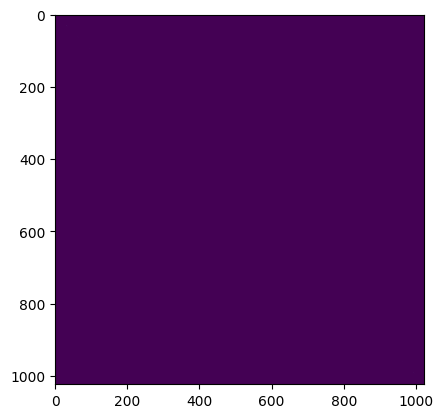

In [35]:
plt.imshow((torch.diag_embed(covariance.get_matrix()[:, :].view(-1))).cpu() * 10000)

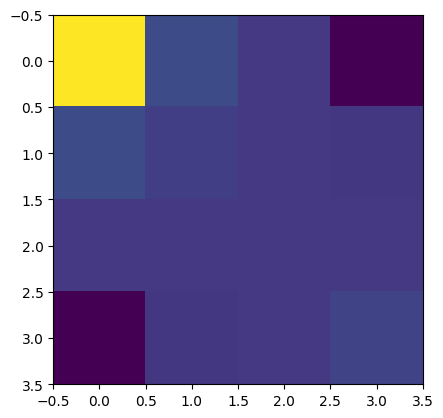

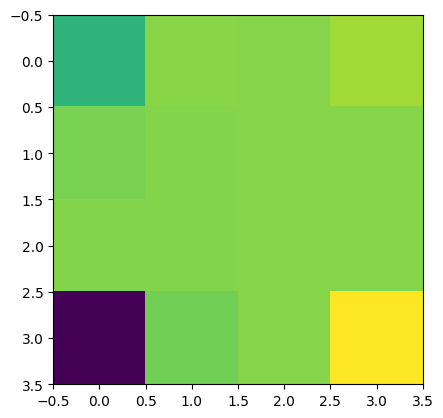

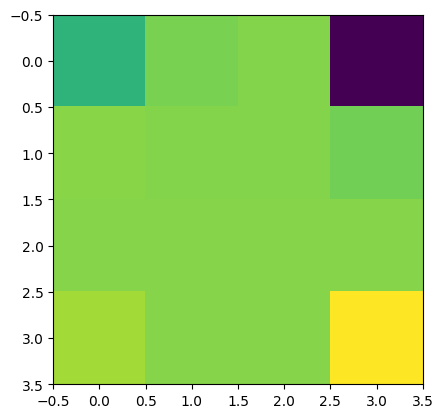

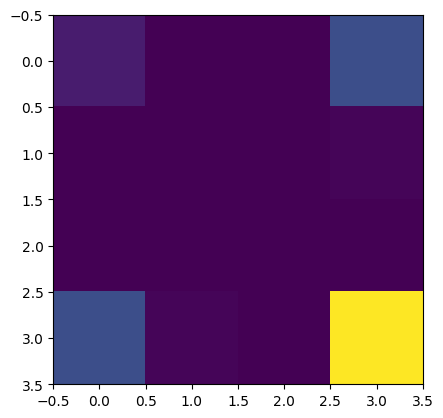

In [31]:
for j in range(4):
    plt.figure()
    plt.imshow(x_wavelet[0,0,j,:,:].cpu().numpy())